# Noisy drive qubit simulation

### Author: Daniel Gonçalves Benvenutti - UNICAMP
02 April 2025

Qutip Version: 5.1.1

This notebooks simulates the effects of a noisy qubit drive on the caracterization of a qubit using the qutip quantum simulation library and the paralelism from qutip's library. The end goal is describing the effects on the decoherence of the qubit, relaxation ($T_1$) and dephasing ($T_2$). See my [decoherence qubit simulation](https://github.com/Danielgb23/superconducting_qubit_3/blob/main/Daniel-simulation-qubit.ipynb) with just the collapse operators for more details on the measurement procedures used in this simulation.

We can see that white noise in the drive doesn't really affect the relaxation of the qubit though it can make the state of the qubit drift on the z axis and it does cause dephasing. Neverthless the amplitude necessary to cause significant damage to the qubit's state is very big, we need a white noise standard deviation equivalent to a resonant drive amplitude that excites the qubit in $50\textrm{ns}$ with a $\pi$ pulse. This makes the qubit really robust against white noise in the drive mostly because the qubit works in a way as a very narrow band pass filter around it't resonant frequency and the white noise is distributed all over the spectrum in the frequency domain.







In [1]:
# to use in google colab
!pip install qutip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.1/30.1 MB 23.0 MB/s eta 0:00:00


In [2]:
import qutip as qtp
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from statsmodels.graphics.tsaplots import plot_acf

## Simulation Parameters



In [73]:
# parameters
wq=3*2*np.pi #qubit resonance frequency [GHz.rad]
Ed=0.01*2*np.pi #driving energy [GHz.rad]

pi_pulse=np.pi/Ed #[ns]
print(f"pi pulse={pi_pulse:.2e}")

T1=2000 #relaxation time [ns]
T2=1000 #dephasing time [ns]

# (T2 must be T2<=2T1)
if T2>2*T1:
  raise Exception("T2 must be T2<=2T1")

# operators
sm=qtp.destroy(2)
sx=qtp.sigmax()
sz=qtp.sigmaz()
sy=qtp.sigmay()
n=sm.dag()*sm

# hamiltonian
def H(wq, Ed_t, tlist):# wq[rad.GHz], Ed_t[rad.GHz], tlist[ns]
  # time independant hamiltonian (normalized by wq)
  if Ed_t is None:
    return -0.5*wq*sz/wq
  # time dependant hamiltonian
  # [time independant part, [operator,time dependant operator amplitude]]
  # [qubit, [drive]]
  return qtp.QobjEvo([-0.5*wq*sz/wq,[sx/wq,Ed_t]],tlist=tlist*wq)

# colapse operators normalized by wq
def c_ops(T1, T2): #T1[ns], T2[ns]
  if T2 is None:
    return [np.sqrt(1/T1/wq)*sm]
  gamma_phi=1/T2-1/2/T1 #pure dephasing constant
  return [np.sqrt(1/T1/wq)*sm,np.sqrt(gamma_phi/2/wq)*sz]
  #return [np.sqrt(1/T1)*sm,np.sqrt(2*gamma_phi)*n] #same thing for dephasing but in different terms



pi pulse=5.00e+01


In [129]:
def plot_tomography(res):
  fig, axes = plt.subplots(3, 1, figsize=(8, 10))  # Adjust figure size as needed

  # Plot sx
  axes[0].plot(t, res.expect[0])
  axes[0].set_xlabel('Time (ns)')
  axes[0].set_ylabel('<σx>')
  axes[0].set_title('Tomography of the noisy oscillation \n Expectation Value of $\sigma_x$')


  # Plot sy
  axes[1].plot(t, res.expect[1])
  axes[1].set_xlabel('Time (ns)')
  axes[1].set_ylabel('<σy>')
  axes[1].set_title('Expectation Value of $\sigma_y$')

  # Plot sz
  axes[2].plot(t, res.expect[2])
  axes[2].set_xlabel('Time (ns)')
  axes[2].set_ylabel('<σz>')
  axes[2].set_title('Expectation Value of $\sigma_z$')


  plt.tight_layout()  # Adjust spacing between subplots
  plt.show()

# White noise in the drive
White noise is the most common form of noise in wave generators. It's made of random fluctuations in the time domain that follow a gaussian distribuition of amplitude. You can see below from the fourier transform of a white noise signal that the frequency probability distribuition of this noise in the frequency domain follows a constant function shape. This is important to understand the influence of this signal on a qubit.

We represent our noise amplitude in terms of multiples of `Ed`$=2\pi \times 10  Mrad/s$, a drive energy equivalent to one that excites a $\pi$ pulse at resonance in $50 ns$ at our qubit. For the disruption of our noise to be significant in our study the amplitude needs to be a few times or even an order of magnitude greater than that reference value.

In [53]:
#White noise generator
tlist=np.linspace(0,500,int(500*3000/wq))
drive_data=0.1*Ed*np.random.normal(0,1, tlist.shape) #10% Ed amplitude

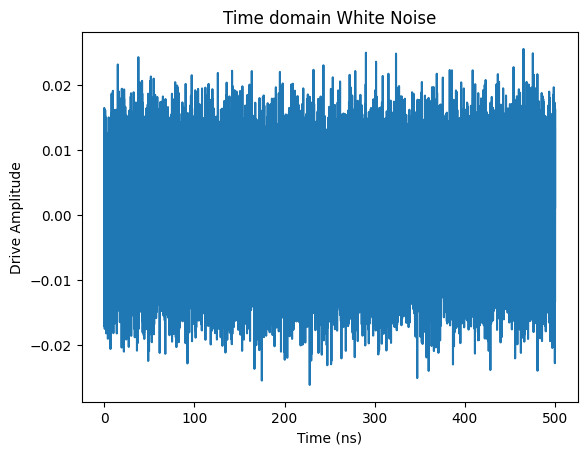

In [54]:
# Define the start and end indices for the portion you want to plot


# Create the plot for a specific range of 'tlist' and 'drive_data'
plt.plot(tlist, drive_data)
plt.xlabel('Time (ns)')
plt.ylabel('Drive Amplitude')
plt.title('Time domain White Noise')
plt.show()

39788


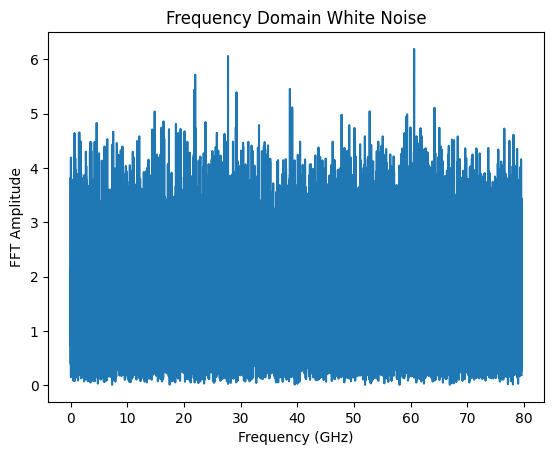

In [39]:
# prompt: plot the fft of drive_data with a proper freq axis

# Calculate the FFT
drive_fft = np.fft.fft(drive_data)

# Calculate the corresponding frequencies
freq = np.fft.fftfreq(len(tlist), d=tlist[1] - tlist[0])

middle=len(freq)//2
print(middle)
# Plot the FFT with proper frequency axis
plt.plot(freq[:middle], np.abs(drive_fft)[:middle])
plt.xlabel('Frequency (GHz)')
plt.ylabel('FFT Amplitude')
plt.title('Frequency Domain White Noise')
plt.show()

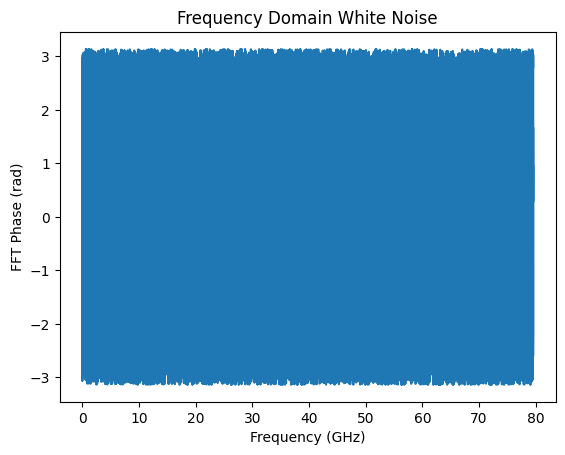

In [40]:
# Assuming 'drive_data' and 'tlist' are defined as in your provided code

# Calculate the FFT
drive_fft = np.fft.fft(drive_data)

# Calculate the corresponding frequencies
freq = np.fft.fftfreq(len(tlist), d=tlist[1] - tlist[0])

# Plot the FFT with proper frequency axis
plt.plot(freq[:middle], np.angle(drive_fft)[:middle])
plt.xlabel('Frequency (GHz)')
plt.ylabel('FFT Phase (rad)')
plt.title('Frequency Domain White Noise')
plt.show()

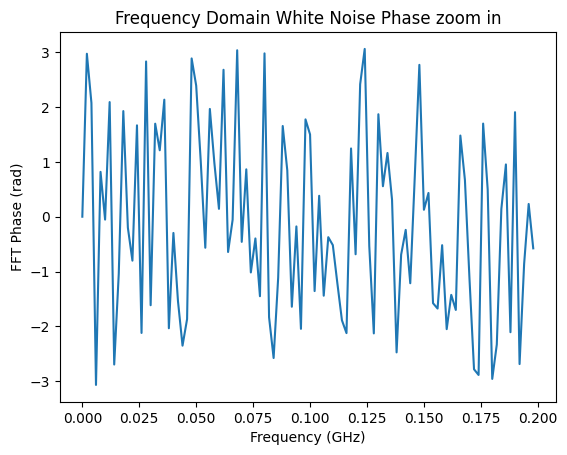

In [41]:
# Plot the FFT with proper frequency axis
plt.plot(freq[0:100], np.angle(drive_fft)[0:100])
plt.xlabel('Frequency (GHz)')
plt.ylabel('FFT Phase (rad)')
plt.title('Frequency Domain White Noise Phase zoom in')
plt.show()

## Pure noise drive


We modify the simulation from the [previous notebook](https://github.com/Danielgb23/superconducting_qubit_3/blob/main/Daniel-simulation-qubit.ipynb) to use a numpy vector with the points of the function instead of using directly the function call. The solver will automatically interpolate this data with a function so that it can integrate our function with randomness for the simulation. If we put randomness directly into the function this will interfere with the integration process.

### 10% of drive amplitude
On the same timescale of the Rabi oscillation qubit simulation notebook mentioned in the introduction we use as drive just the white noise with an amplitude (read standard deviation) of 10% of the previous drive ampltude `Ed`. We can see that the noise does very little to the state of the qubit.

In [99]:
#White noise generator
tlist=np.linspace(0,500,int(500*3000/wq))
drive_data=0.1*Ed*np.random.normal(0,1, tlist.shape) #10% Ed amplitude

In [100]:
# initial state
psi0=qtp.basis(2,0)
t=np.linspace(0,500,1000) #ns
res=qtp.mesolve(H(wq,drive_data,tlist),psi0,t*wq,e_ops=[sx, sy, sz],options=dict(nsteps=5000))

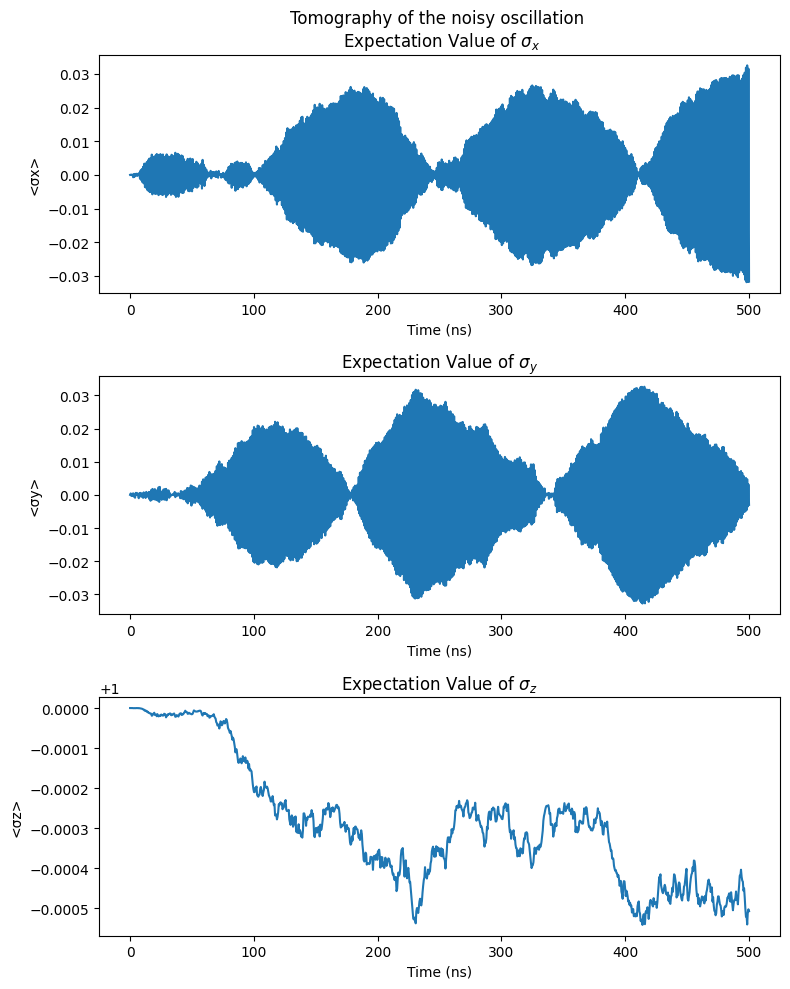

In [101]:
# prompt: Generate a plot of the three expectation values sx, sy, sz from res expect using t as x axis in different subplots

plot_tomography(res)

### Higher amplitude noise (20x)
Now with 20 times the amplitude `Ed` we can see a very significant influence of the noise on the qubit on this time scale. Which depending on the signal can even flip it's state. The evolution of the qubit's state seem to follow a random walk. But by doing the autocorrelation the seems to form a logarithm curve it's not a random walk per se.

In [102]:
#With 20 times the Ed amplitude
# initial state
psi0=qtp.basis(2,0)
t=np.linspace(0,500,1000) #ns
res=qtp.mesolve(H(wq,drive_data*200,tlist),psi0,t*wq,e_ops=[sx, sy, sz],options=dict(nsteps=5000))

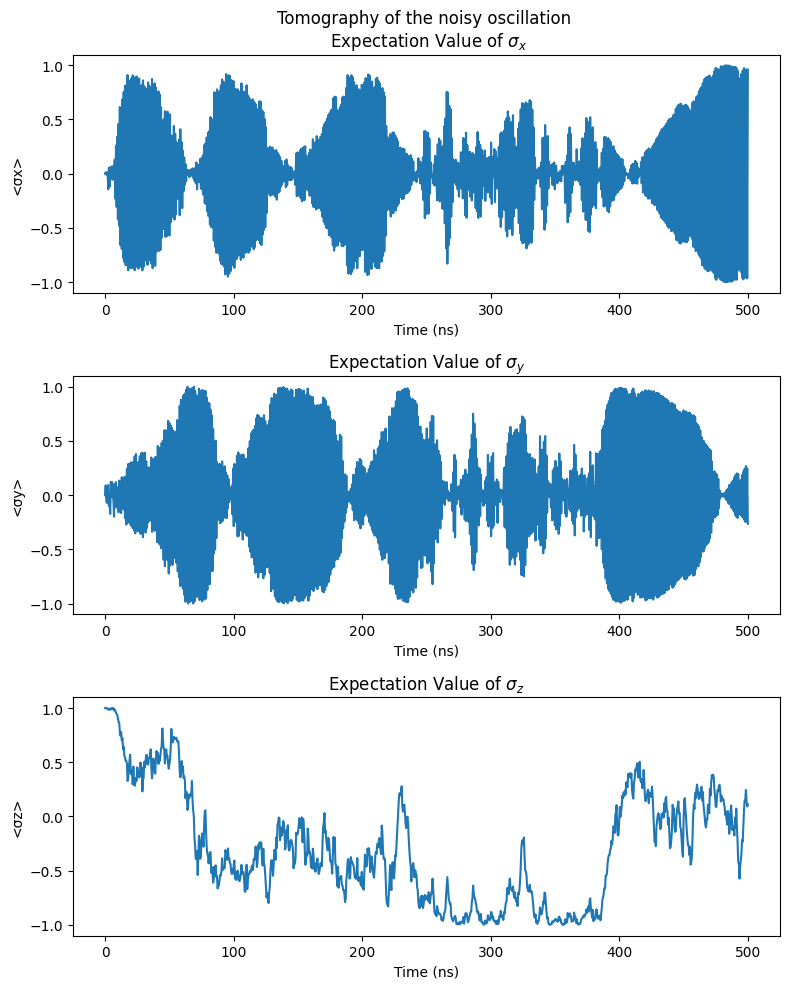

In [106]:
plot_tomography(res)

Autocorrelation of the output expected value of the $\sigma_z$ operator. This graph below shows the correlation between increasingly greater time intervals of the data. We can see that there is a much higher correlation between close values and distant values loose this correlation in a non linear fashion/curve. If the evolution of the qubit was a random walk we would see a linear graph: See [White Noise and Random Walks in Time Series Analysis](https://www.quantstart.com/articles/White-Noise-and-Random-Walks-in-Time-Series-Analysis/).

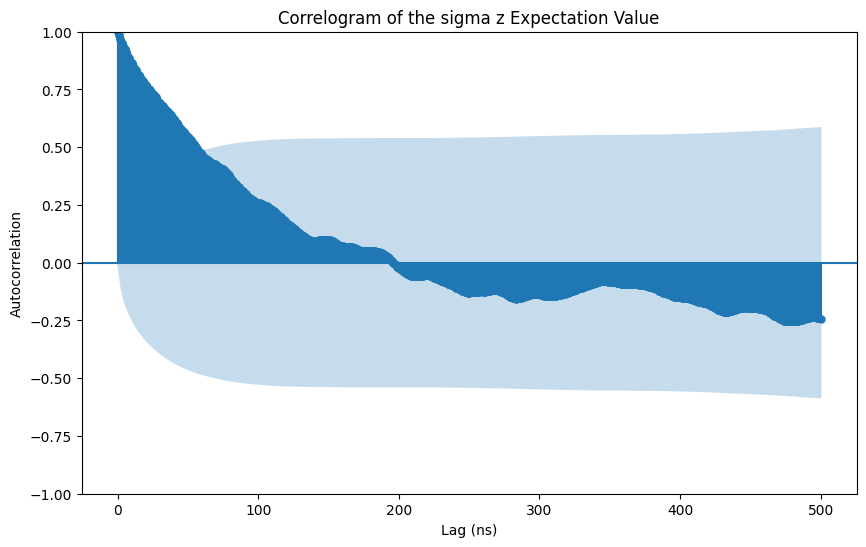

In [105]:
# prompt: Do a correlogram of the sz expectation value using acf function

# Calculate the difference of the sz expectation value
sz_diff = np.diff(res.expect[2])

# Create the correlogram
fig, ax = plt.subplots(figsize=(10, 6))
plot_acf(res.expect[2],  ax=ax, lags=t) # Use all available lags for the plot

ax.set_xlabel('Lag (ns)')
ax.set_ylabel('Autocorrelation')
ax.set_title('Correlogram of the sigma z Expectation Value')

plt.show()


### Simulation with relaxation and dephasing
Here we introduce low coefficients of relaxation and dephasing

$T_1 = 200ns$

$T_2 = 100ns$

for the collapse operators to see the difference in the evolution of the qubit with the 20x noise signal (with the exact same noise). We can see that these effects hinder the qubit from flipping and attaining the excited state.

In [107]:
#With 20 times the Ed amplitude
# initial state
psi0=qtp.basis(2,0)
t=np.linspace(0,500,1000) #ns
res=qtp.mesolve(H(wq,drive_data*200,tlist),psi0,t*wq,c_ops(T1=200,T2=100),e_ops=[sx, sy, sz],options=dict(nsteps=5000))

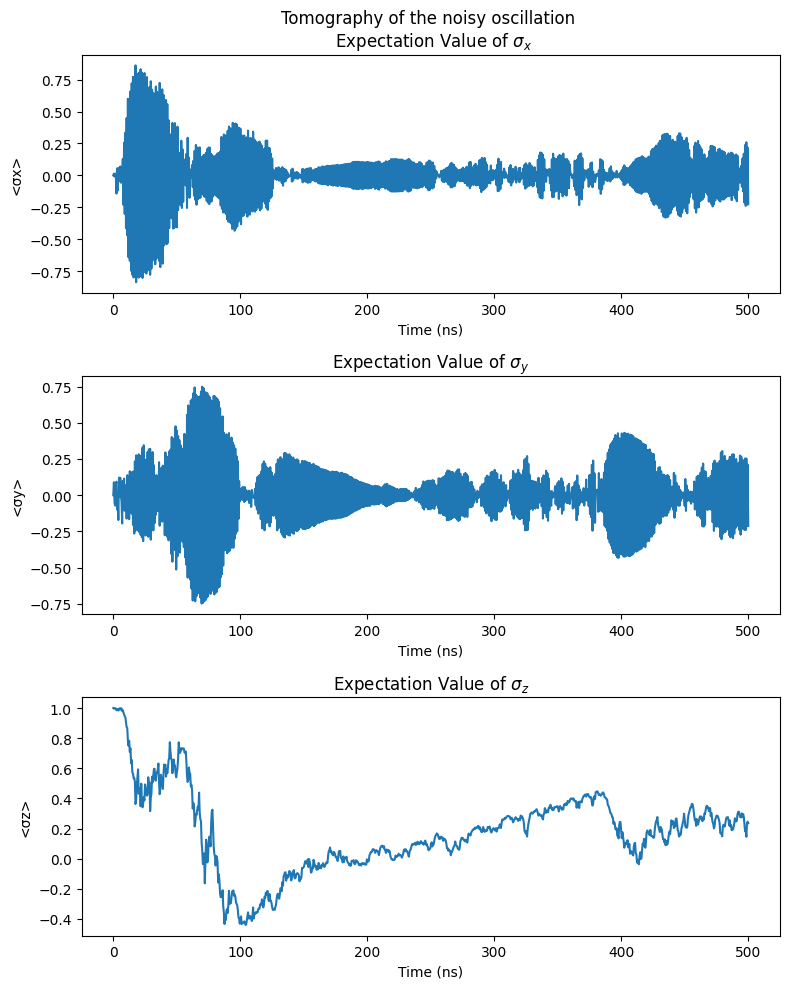

In [108]:
plot_tomography(res)

## Rabi oscillation with noise

In this part we do the process of a Rabi oscillation but with added noise on the drive signal.

### Background noise
Here we use an already very significant background white noise of 10% of the amplitude of the drive signal and we can see that the influence it has on the Rabi oscillation is imperceptible as we saw the little influence it had on the 10% pure noise simulation. We can conclude from this and the study of the physics behind the drive process that the qubit works as a very narrow band pass filter where the noise, whose energy is distributed around all the spectrum, has little energy to contribute to the process of evolution of the Rabi oscillation.

In [146]:
#signal parameters
Det=0 # [GHz]
wd=wq+Det*2*np.pi # [rad.GHz]
tlist=np.linspace(0,500,int(500*3000/wq)) # ns
pure_drive=lambda t: Ed*(np.sin(wd*t))
drive_data=pure_drive(tlist)+Ed*0.1*np.random.normal(0,1, tlist.shape)

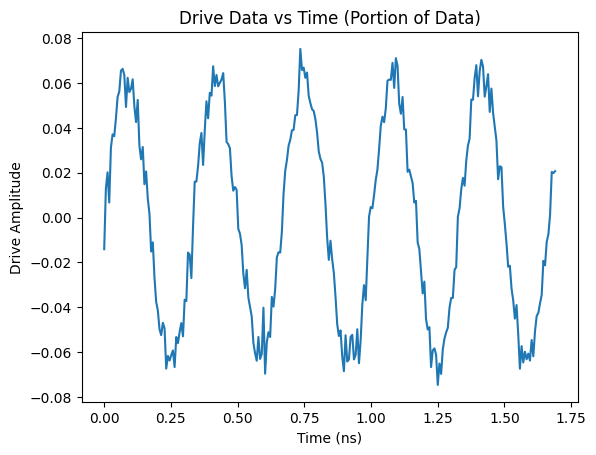

In [147]:

# Define the start and end indices for the portion you want to plot
start_index = 0
end_index = int(32/wq/500*len(tlist))  # Adjust as needed

# Create the plot for a specific range of 'tlist' and 'drive_data'
plt.plot(tlist[start_index:end_index], drive_data[start_index:end_index])
plt.xlabel('Time (ns)')
plt.ylabel('Drive Amplitude')
plt.title('Drive Data vs Time (Portion of Data)')
plt.show()


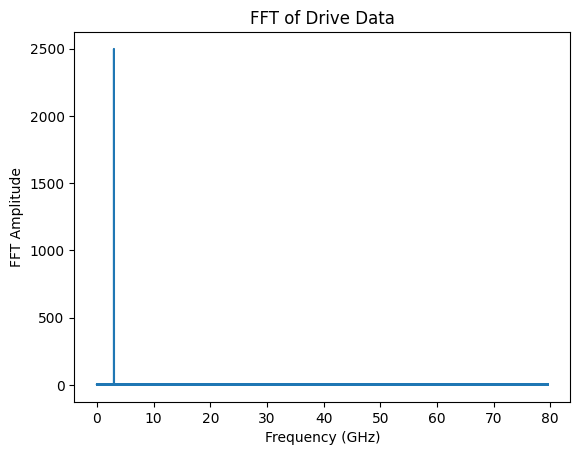

In [148]:
# prompt: plot the fft of drive_data with a proper freq axis

# Calculate the FFT
drive_fft = np.fft.fft(drive_data)

# Calculate the corresponding frequencies
freq = np.fft.fftfreq(len(tlist), d=tlist[1] - tlist[0])
middle=len(freq)//2
# Plot the FFT with proper frequency axis
plt.plot(freq[:middle], np.abs(drive_fft)[:middle])
plt.xlabel('Frequency (GHz)')
plt.ylabel('FFT Amplitude')
plt.title('FFT of Drive Data')
plt.show()


In [127]:
# initial state
psi0=qtp.basis(2,0)
t=np.linspace(0,500,1000) #ns
res=qtp.mesolve(H(wq,drive_data,tlist),psi0,t*wq,c_ops(T1, T2),e_ops=[sx, sy, sz],options=dict(nsteps=5000))

# rabi osc pi pulse
i=np.argmax(res.expect[0])
print("pi pulse:", t[i])


pi pulse: 174.1741741741742


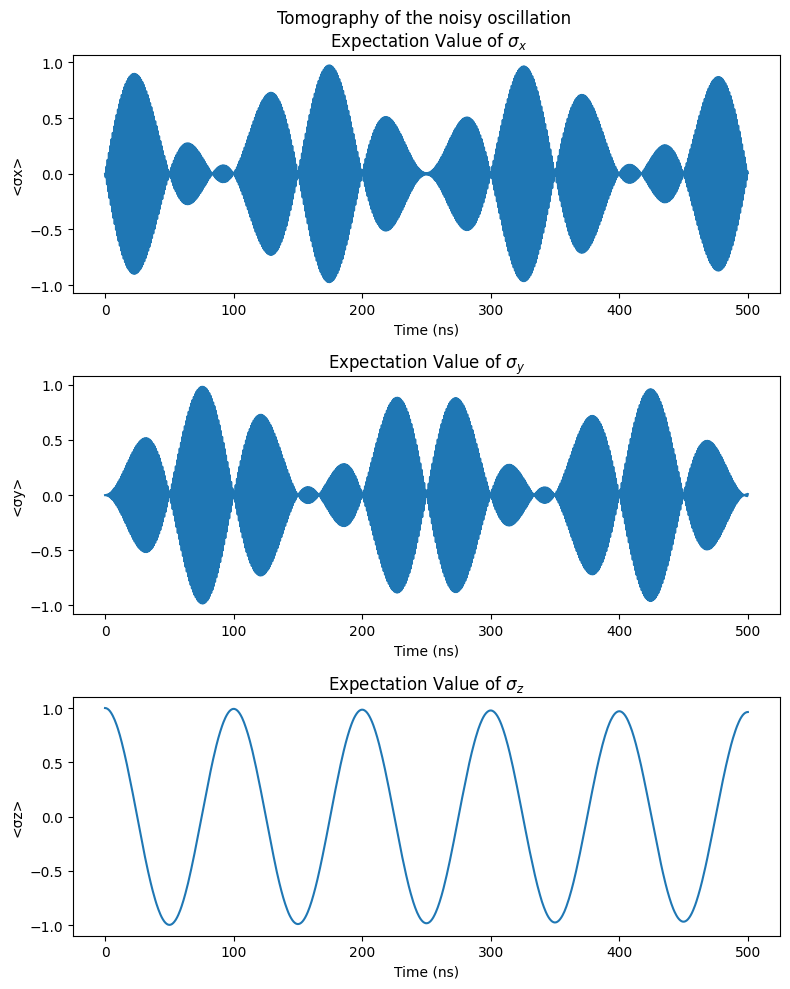

In [130]:
plot_tomography(res)

### Background noise 10x
Here we use a much larger noise of about 10x the amplitude of the drive excitation signal. We can see in the time domain signal plot below that the noise makes the excitation sine wave imperceptible behind the extremely noisy background. Though the frequency domain plot shows how it is still much more significant than the white noise and we can see the same in the evolution of the qubit. But now we can also see the influence of the noise on this evolution that distorts a little the sinusoidal Rabi oscillation.

The conclusion we can get from this simulation is that the qubit is very robust against white noise given that it is only excited by a very narrow band of frequencies that needs to be specifically targeted.

In [149]:
#signal parameters
Det=0 # [GHz]
wd=wq+Det*2*np.pi # [GHz]
tlist=np.linspace(0,500,int(500*3000/wq)) # ns
pure_drive=lambda t: Ed*(np.sin(wd*t))
drive_data=pure_drive(tlist)+Ed*10*np.random.normal(0,1, tlist.shape)

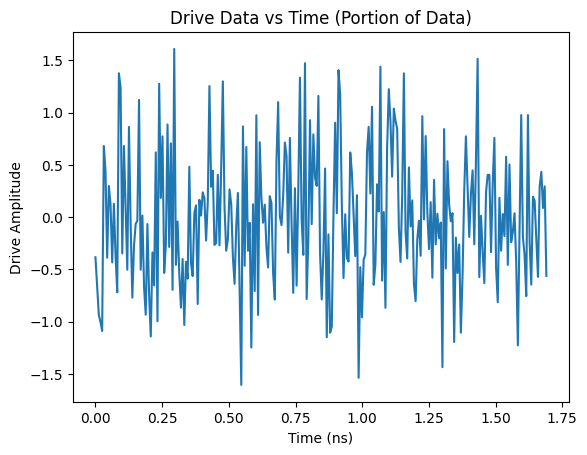

In [142]:

# Define the start and end indices for the portion you want to plot
start_index = 0
end_index = int(32/wq/500*len(tlist))  # Adjust as needed

# Create the plot for a specific range of 'tlist' and 'drive_data'
plt.plot(tlist[start_index:end_index], drive_data[start_index:end_index])
plt.xlabel('Time (ns)')
plt.ylabel('Drive Amplitude')
plt.title('Drive Data vs Time (Portion of Data)')
plt.show()


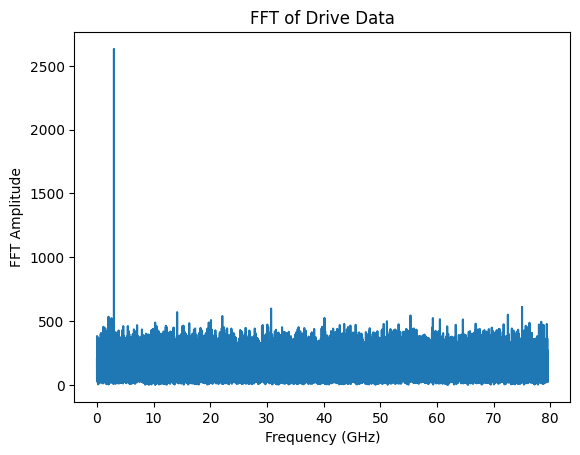

In [144]:
# prompt: plot the fft of drive_data with a proper freq axis

# Calculate the FFT
drive_fft = np.fft.fft(drive_data)

# Calculate the corresponding frequencies
freq = np.fft.fftfreq(len(tlist), d=tlist[1] - tlist[0])
middle=len(freq)//2
# Plot the FFT with proper frequency axis
plt.plot(freq[:middle], np.abs(drive_fft)[:middle])
plt.xlabel('Frequency (GHz)')
plt.ylabel('FFT Amplitude')
plt.title('FFT of Drive Data')
plt.show()


In [139]:
# initial state
psi0=qtp.basis(2,0)
t=np.linspace(0,500,1000) #ns
res=qtp.mesolve(H(wq,drive_data,tlist),psi0,t*wq,c_ops(T1, T2),e_ops=[sx, sy, sz],options=dict(nsteps=5000))

# rabi osc pi pulse
i=np.argmax(res.expect[0])
print("pi pulse:", t[i])


pi pulse: 323.82382382382383


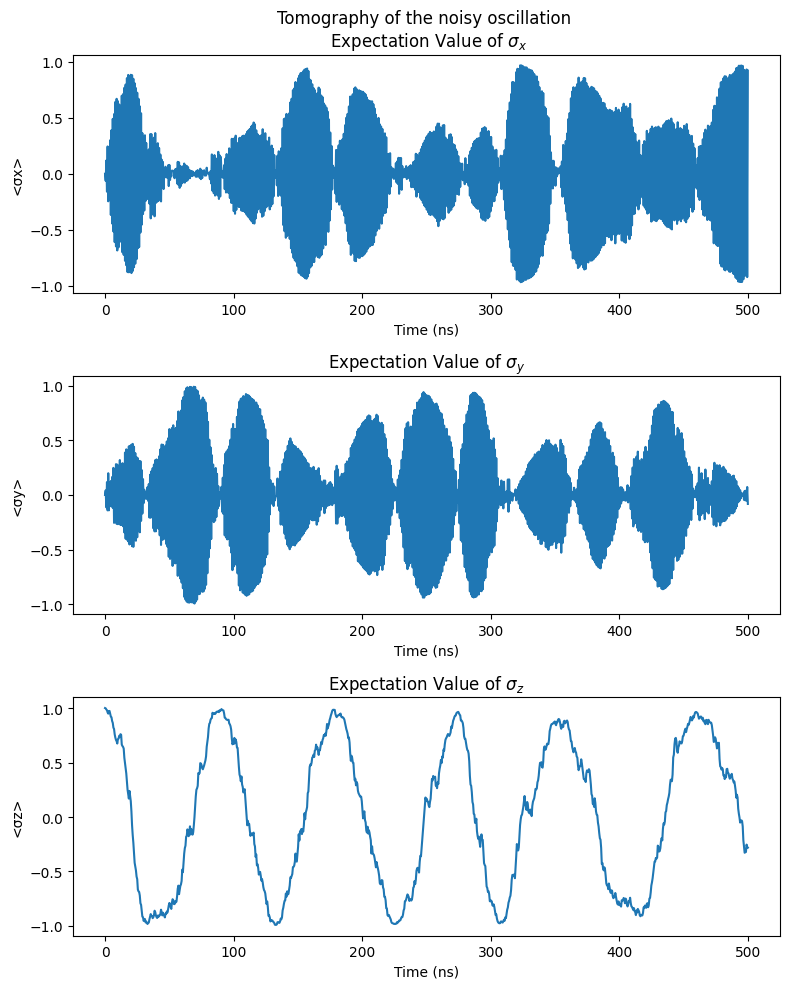

In [140]:
plot_tomography(res)

# $T_1$ simulation


## Pi pulse excitation only noise simulation
Here we can conclude that the noise in the drive only affects the qubit as long as it's active as well as taking it to it's final state when the drive is off. From there on at least the relaxation works independently of the drive's background white noise.

In [196]:
#signal parameters
Det=0 # [GHz]

pi_pulse=np.pi/Ed # ns

wd=wq+Det*2*np.pi # [GHz]
tlist=np.linspace(0,pi_pulse+1,int(pi_pulse*3000/wq)) # ns
pure_drive=lambda t: Ed*(np.sin(wd*t))
drive_data=pure_drive(tlist)+Ed*10*np.random.normal(0,1, tlist.shape)

In [198]:
# initial state
psi0=qtp.basis(2,0)

# times
# times for pi pulse simulation
t_pi_vec=np.linspace(0,pi_pulse,1000) #ns
t=np.linspace(0,6000,10000) #ns

# time dep
res_exc=qtp.mesolve(H(wq,drive_data, tlist),psi0,t_pi_vec*wq,c_ops(T1,T2),options={"store_final_state":True, "nsteps":10000})
#time indp
res=qtp.mesolve(H(wq,None, None),res_exc.final_state,t*wq,c_ops(T1,T2),e_ops=[n])


<ipython-input-199-34e7a8cbe131>:8: OptimizeWarning: Covariance of the parameters could not be estimated
  params, covariance = curve_fit(exponential_func, t, res.expect[0], p0=[1, 2000, 0])  # Initial guess for parameters


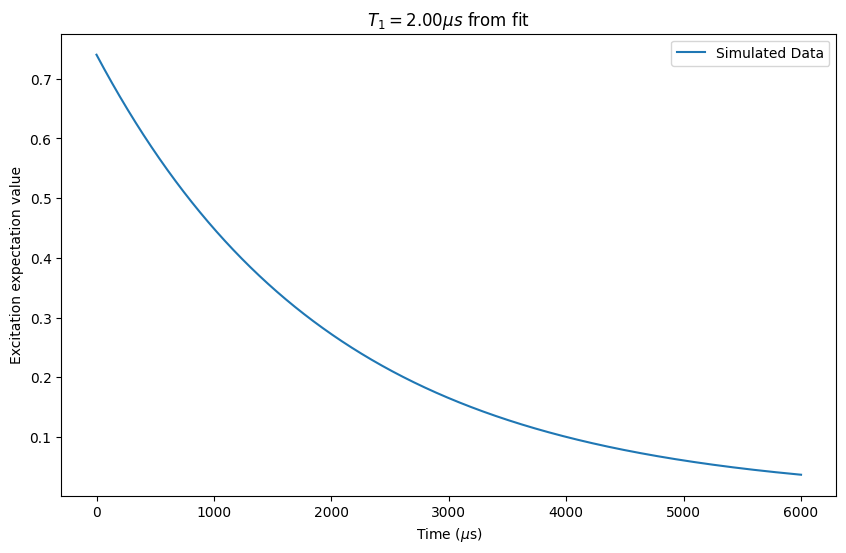

In [199]:
# prompt: prompt: plot res.expect[0] as scatter and fit it with an exponential

# Define the exponential function for fitting
def exponential_func(x, a, tau, c):
    return a * np.exp(- x/tau) + c

# Fit the exponential function to the data
params, covariance = curve_fit(exponential_func, t, res.expect[0], p0=[1, 2000, 0])  # Initial guess for parameters

# Extract fitted parameters
a, tau, c = params

# Generate fitted curve
fitted_curve = exponential_func(t, a, tau, c)


# Plotting
fig, axes = plt.subplots(1, 1, figsize=(10, 6))
axes.plot(t, res.expect[0], label='Simulated Data')
axes.set_xlabel('Time ($\mu$s)')
axes.set_ylabel('Excitation expectation value')
axes.set_title(f'$T_1= {tau/1e3:.2f}\mu s$ from fit')
axes.legend()
plt.show()


## Noisy background $T_1$ decay (100% of the drive signal amplitude)
Here we can verify again that the noise in the drive has no influence on the relaxation decay unless it's high enough to just mask it.


In [4]:
tlist=np.linspace(0,6000,int(6000*3000/wq)) # ns

background=Ed*1*np.random.normal(0,1, tlist.shape)


In [209]:
t=np.linspace(0,6000,10000) #ns

# time dependant decay
# repurposes res_exc from previous simulation
res=qtp.mesolve(H(wq,background, tlist),res_exc.final_state,t*wq,c_ops(T1,T2),e_ops=[n])

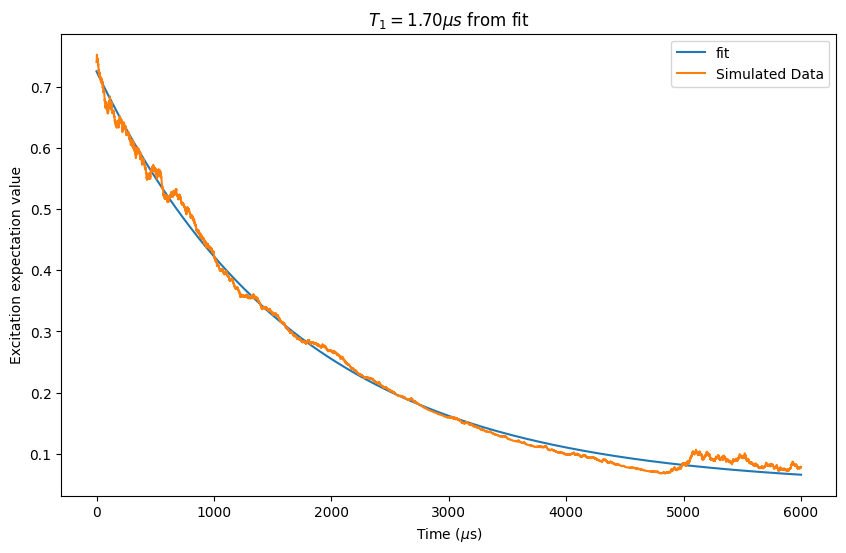

In [210]:
# prompt: prompt: plot res.expect[0] as scatter and fit it with an exponential

# Define the exponential function for fitting
def exponential_func(x, a, tau, c):
    return a * np.exp(- x/tau) + c

# Fit the exponential function to the data
params, covariance = curve_fit(exponential_func, t, res.expect[0], p0=[1, 2000, 0])  # Initial guess for parameters

# Extract fitted parameters
a, tau, c = params

# Generate fitted curve
fitted_curve = exponential_func(t, a, tau, c)


# Plotting
fig, axes = plt.subplots(1, 1, figsize=(10, 6))
axes.plot(t, fitted_curve, label='fit')
axes.plot(t, res.expect[0], label='Simulated Data')
axes.set_xlabel('Time ($\mu$s)')
axes.set_ylabel('Excitation expectation value')
axes.set_title(f'$T_1= {tau/1e3:.2f}\mu s$ from fit')
axes.legend()
plt.show()

# $T_2$ Ramsey Simulation




## Noisy drive, no dephasing collapse operator

Here we are using simulations without the dephasing collapse operator (by putting None in T2 on the c_ops function) to isolate the dephasing effects of the noise. We do several simulations with different degrees of noise and compare the $T_2^*$ obtained with the expected $T_2^*=2T_1 = 4\mu s$ from the relationship $\frac{1}{T_2}=\frac{1}{2T_1}+\frac{1}{T_\phi}$ . Since the $T_2^*$ gets worse as we increase the noise the conclusion is that the noise in the pulse either causes dephasing on the qubit or that it makes the dephasing appear worse in our measurement.

The phase of the qubit is more sensitive to white noise in the drive. While we need a 20x`Ed` signal to disrupt the $\sigma_z$ expected value a 5x to 8x noise will already cause very significant dephasing.

In [90]:
def plot_ramsey(T,exp, T2_guess=2*T1):
  # prompt: plot exp and t as a ramsey oscillation with a damped sine fit

  def damped_sine(t, amplitude, frequency, tau, phase, offset):
    return amplitude * np.exp( - t/tau) * np.sin(2 * np.pi * frequency * t + phase) + offset

  params, covariance = curve_fit(damped_sine, T, exp, p0=[0.5, 0.002, T2_guess, 0, 0.5])

  amplitude, frequency, decay_constant, phase, offset = params
  t=np.linspace(T[0],T[-1],len(T)*10)
  fitted_exp = damped_sine(t, amplitude, frequency, decay_constant, phase, offset)

  fig, axes = plt.subplots(1, 1, figsize=(10,6))
  axes.plot(T, exp, label='Simulated Data')
  axes.plot(t, fitted_exp, label='Damped Sine Fit')
  axes.set_xlabel('Time (ns)')
  axes.set_ylabel('Excitation expectation value')
  axes.set_title(f'Ramsey Oscillation with Damped Sine Fit $T_2^*$={params[2]*1e-3:.2f}$\mu s$')
  axes.legend()
  plt.show()

In [91]:
# initial state
psi0=qtp.basis(2,0)

 #drive parameters
Det=0.002 #[GHz]
pi2_pulse=np.pi/Ed/2 # [ns]
wd=wq+Det*2*np.pi # [rad.GHz]
pure_drive=lambda t: Ed*(np.sin(wd*t)) # [rad.GHz]

T2=None

# time values for the time dependant simulation during excitation
# The time dependant part of the simulation is usually a bottleneck
# less points doesn't necessarily means less time/work

step=2 # ns
pi2_vec=np.linspace(0,pi2_pulse,256) # ns

# dictionary with simulation options
# for T2 simulations we need higher numerical precision
# so we set atol and rtol that limit the (estimated) error
# per integration step to be smaller
options={"store_final_state":True,"nsteps":10000, "atol":1e-10,"rtol":1e-8}

def ramsey(T, noise_amp=0,Ed=Ed):
  # Ramsey simulation with interrogation time T in [ns] and detuning Det in [GHz]

  # The ramsey osccillation is more inefficient to simulate than Rabi
  # Because you need to evolve the whole simulation for each interrogation time



  # Times for the free oscillation time independant simulation
  step=1 # ns
  t=np.arange(0,T+step,step) # ns

  #first drive pulse
  tlist=np.linspace(0,pi2_pulse+1,int(pi2_pulse*3000/wq)) # [ns]
  drive_data=pure_drive(tlist)+Ed*noise_amp*np.random.normal(0,1, tlist.shape) # [rad.GHz]


  # pi/2 pulse simulation with time dependant hamiltonian
  # it just simulates an excitation drive and returns the final state in the res_exc
  res=qtp.mesolve(H(wq,drive_data,tlist),psi0,pi2_vec*wq,c_ops(T1,T2),options=options)

  # shift to keep the phase consistent
  shift=pi2_vec[-1]

  # for T=0 or smaller than step not to throw an error
  if T>=step:
    #Ramsey free evolution simulation
    res=qtp.mesolve(H(wq,None,None),res.final_state,wq*(t+shift),c_ops(T1,T2),options=options)
    shift+=t[-1]


  #second drive pulse
  tlist=shift+np.linspace(0,pi2_pulse+1,int(pi2_pulse*3000/wq)) # [ns]
  drive_data=pure_drive(tlist)+Ed*noise_amp*np.random.normal(0,1, tlist.shape) # [rad.GHz]

  # second ramsey pulse
  res=qtp.mesolve(H(wq,drive_data,tlist),res.final_state,wq*(pi2_vec+shift),c_ops(T1,T2),options=options)

  # return excitation expected value of the final state like a measurement
  return qtp.expect(n,res.final_state)



## No noise

In [94]:
# interrogation times
T=np.linspace(0,4000,64) #ns
def wrap_ramsey(T):
  return ramsey(T,noise_amp=0)
# qutip's parallelism "map()" like function to evaluate all points in T using Ramsey
exp=list(qtp.parallel_map(wrap_ramsey,T,progress_bar=True))


10.9%. Run time:   2.39s. Est. time left: 00:00:00:19
20.3%. Run time:   8.29s. Est. time left: 00:00:00:32
31.2%. Run time:  17.12s. Est. time left: 00:00:00:37
40.6%. Run time:  27.80s. Est. time left: 00:00:00:40
50.0%. Run time:  41.28s. Est. time left: 00:00:00:41
60.9%. Run time:  60.91s. Est. time left: 00:00:00:39
70.3%. Run time:  79.58s. Est. time left: 00:00:00:33
81.2%. Run time: 105.79s. Est. time left: 00:00:00:24
90.6%. Run time: 130.78s. Est. time left: 00:00:00:13
100.0%. Run time: 155.90s. Est. time left: 00:00:00:00
Total run time: 155.94s


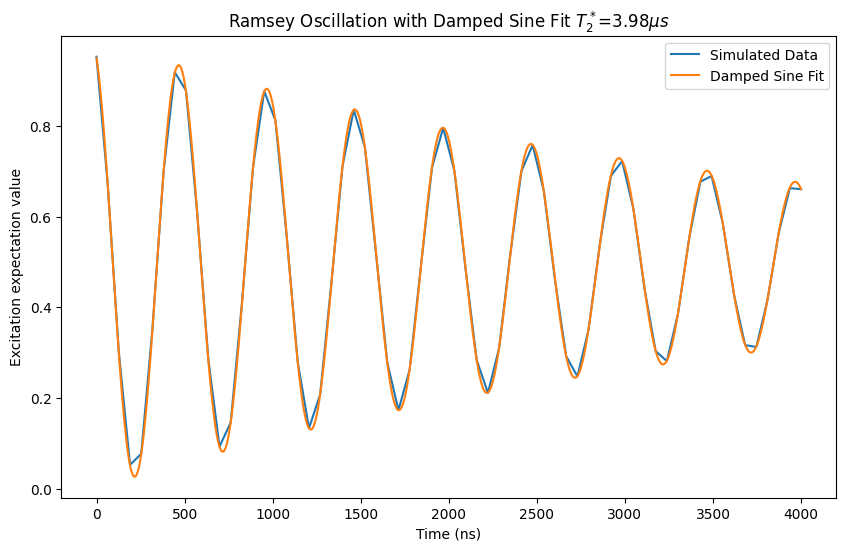

In [93]:
plot_ramsey(T,exp)

### 0.5 times drive amplitude (Ed) standard deviations of white noise

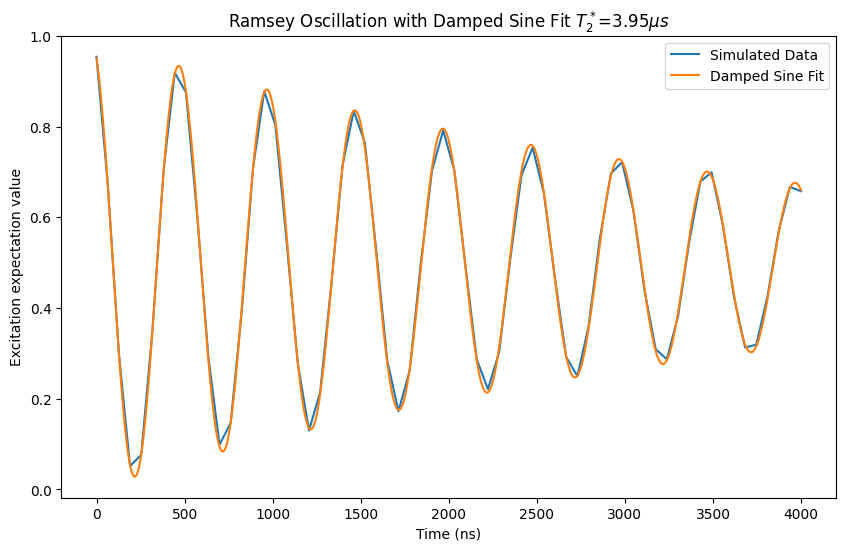

In [98]:
T=np.linspace(0,4000,64) #ns
def wrap_ramsey(T):
  return ramsey(T,noise_amp=0.5)
exp=list(qtp.parallel_map(wrap_ramsey,T))
plot_ramsey(T,exp)

### 1 time Ed

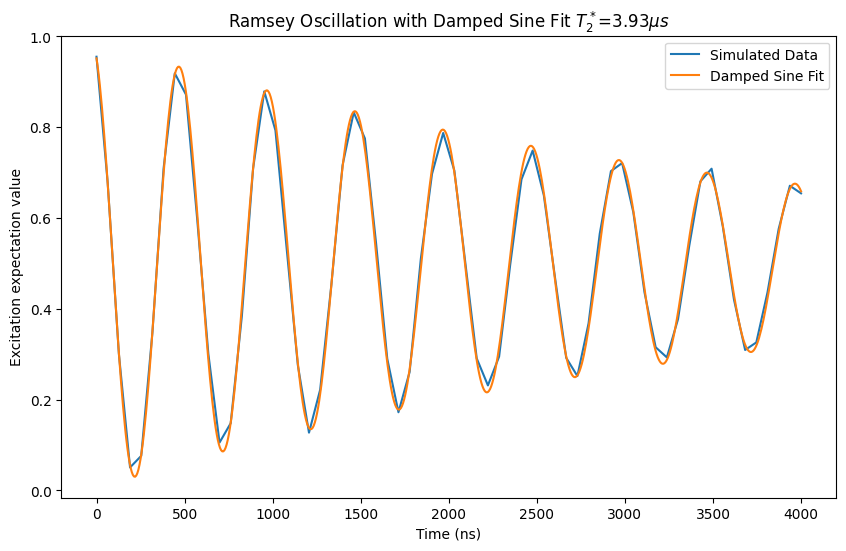

In [99]:
T=np.linspace(0,4000,64) #ns
def wrap_ramsey(T):
  return ramsey(T,noise_amp=1)
exp=list(qtp.parallel_map(wrap_ramsey,T))
plot_ramsey(T,exp)

### 2 times Ed

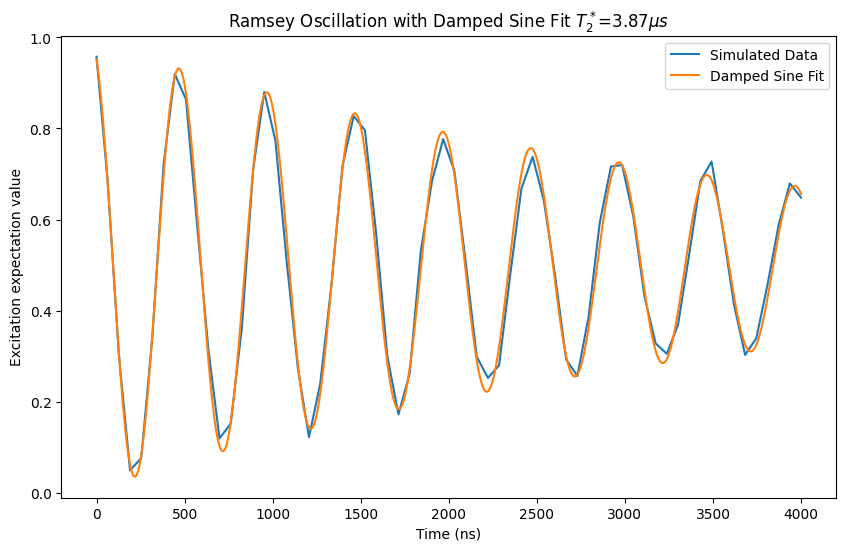

In [100]:
T=np.linspace(0,4000,64) #ns
def wrap_ramsey(T):
  return ramsey(T,noise_amp=2)
exp=list(qtp.parallel_map(wrap_ramsey,T))
plot_ramsey(T,exp)

### 5 times Ed

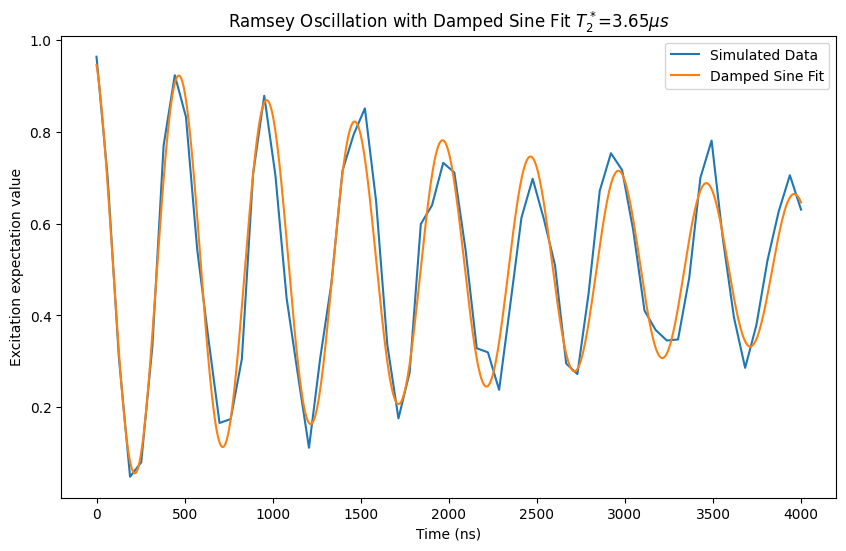

In [101]:
T=np.linspace(0,4000,64) #ns
def wrap_ramsey(T):
  return ramsey(T,noise_amp=5)
exp=list(qtp.parallel_map(wrap_ramsey,T))
plot_ramsey(T,exp)

### 8 times Ed

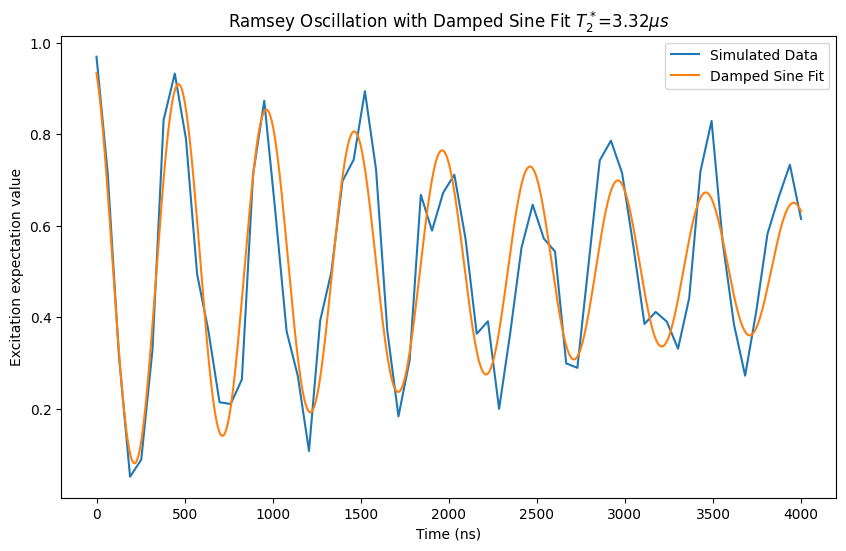

In [102]:
T=np.linspace(0,4000,64) #ns
def wrap_ramsey(T):
  return ramsey(T,noise_amp=8)
exp=list(qtp.parallel_map(wrap_ramsey,T))
plot_ramsey(T,exp)

## Background noise in the between pulse interval
We can see a more signifiant dephasing if we have background noise in the time in between the Ramsey $\pi /2$ pulses. The dephasing worsens with the noise amplitude until at about 5x `Ed` we can't even properly fit the curve to measure the dephasing.

In [113]:
# initial state
psi0=qtp.basis(2,0)

 #drive parameters
Det=0.002 #[GHz]
pi2_pulse=np.pi/Ed/2 # [ns]
wd=wq+Det*2*np.pi # [rad.GHz]
pure_drive=lambda t: Ed*(np.sin(wd*t)) # [rad.GHz]

T2=None

# time values for the time dependant simulation during excitation
# The time dependant part of the simulation is usually a bottleneck
# less points doesn't necessarily means less time/work

step=2 # ns
pi2_vec=np.linspace(0,pi2_pulse,256) # ns

# dictionary with simulation options
# for T2 simulations we need higher numerical precision
# so we set atol and rtol that limit the (estimated) error
# per integration step to be smaller
options={"store_final_state":True,"nsteps":10000, "atol":1e-10,"rtol":1e-8}

def noisy_T_ramsey(T, noise_amp=0,T_noise=0,Ed=Ed):
  # Ramsey simulation with interrogation time T in [ns] and detuning Det in [GHz]

  # The ramsey osccillation is more inefficient to simulate than Rabi
  # Because you need to evolve the whole simulation for each interrogation time



  # Times for the free oscillation time independant simulation
  step=4 # ns
  t=np.arange(0,T+step,step) # ns

  #first drive pulse
  tlist=np.linspace(0,pi2_pulse+1,int(pi2_pulse*3000/wq)) # [ns]
  drive_data=pure_drive(tlist)+Ed*noise_amp*np.random.normal(0,1, tlist.shape) # [rad.GHz]


  # pi/2 pulse simulation with time dependant hamiltonian
  # it just simulates an excitation drive and returns the final state in the res_exc
  res=qtp.mesolve(H(wq,drive_data,tlist),psi0,pi2_vec*wq,c_ops(T1,T2),options=options)

  # shift to keep the phase consistent
  shift=pi2_vec[-1]

  # for T=0 or smaller than step not to throw an error
  if T>=step:
    tlist=shift+np.arange(0,T+1,100/wq) # [ns]
    noise_data=Ed*T_noise*np.random.normal(0,1, tlist.shape) # [rad.GHz]
    #Ramsey free evolution simulation
    res=qtp.mesolve(H(wq,noise_data,tlist),res.final_state,wq*(t+shift),c_ops(T1,T2),options=options)
    shift+=t[-1]


  #second drive pulse
  tlist=shift+np.linspace(0,pi2_pulse+1,int(pi2_pulse*3000/wq)) # [ns]
  drive_data=pure_drive(tlist)+Ed*noise_amp*np.random.normal(0,1, tlist.shape) # [rad.GHz]

  # second ramsey pulse
  res=qtp.mesolve(H(wq,drive_data,tlist),res.final_state,wq*(pi2_vec+shift),c_ops(T1,T2),options=options)

  # return excitation expected value of the final state like a measurement
  return qtp.expect(n,res.final_state)

### 1 time Ed

10.9%. Run time:   2.82s. Est. time left: 00:00:00:22
20.3%. Run time:   9.04s. Est. time left: 00:00:00:35
31.2%. Run time:  19.74s. Est. time left: 00:00:00:43
40.6%. Run time:  32.84s. Est. time left: 00:00:00:48
50.0%. Run time:  49.52s. Est. time left: 00:00:00:49
60.9%. Run time:  73.74s. Est. time left: 00:00:00:47
70.3%. Run time:  97.89s. Est. time left: 00:00:00:41
81.2%. Run time: 128.55s. Est. time left: 00:00:00:29
90.6%. Run time: 160.09s. Est. time left: 00:00:00:16
100.0%. Run time: 191.56s. Est. time left: 00:00:00:00
Total run time: 191.58s


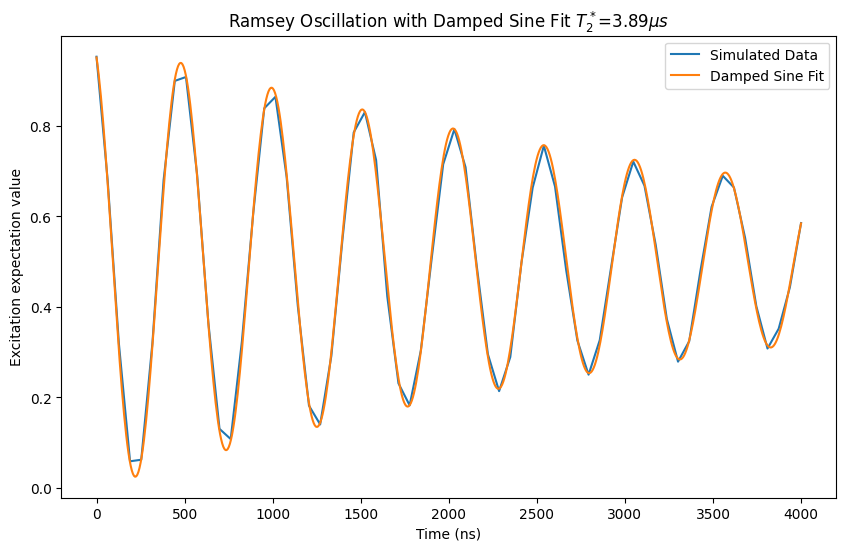

In [116]:
T=np.linspace(0,4000,64) #ns
def wrap_ramsey(T):
  return noisy_T_ramsey(T,noise_amp=0, T_noise=1)
exp=list(qtp.parallel_map(wrap_ramsey,T,progress_bar=True))
plot_ramsey(T,exp)

### 1.5 times Ed

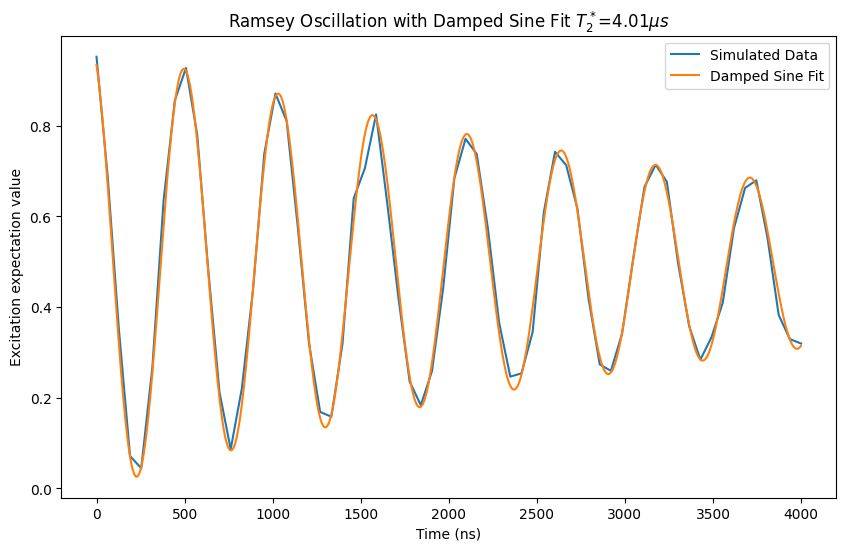

In [119]:
T=np.linspace(0,4000,64) #ns
def wrap_ramsey(T):
  return noisy_T_ramsey(T,noise_amp=0, T_noise=1.5)
exp=list(qtp.parallel_map(wrap_ramsey,T,))#progress_bar=True))
plot_ramsey(T,exp)

### 2 times Ed

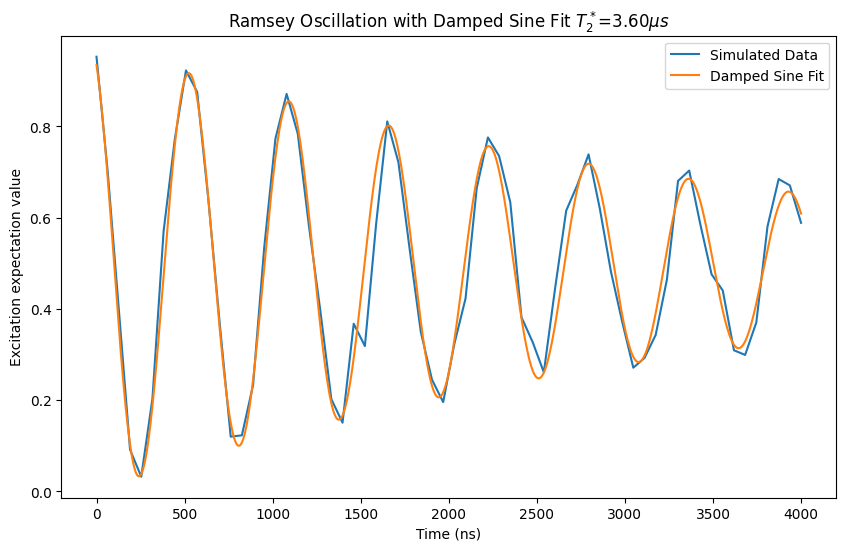

In [120]:
T=np.linspace(0,4000,64) #ns
def wrap_ramsey(T):
  return noisy_T_ramsey(T,noise_amp=0, T_noise=2)
exp=list(qtp.parallel_map(wrap_ramsey,T,))#progress_bar=True))
plot_ramsey(T,exp)

### 3 times Ed

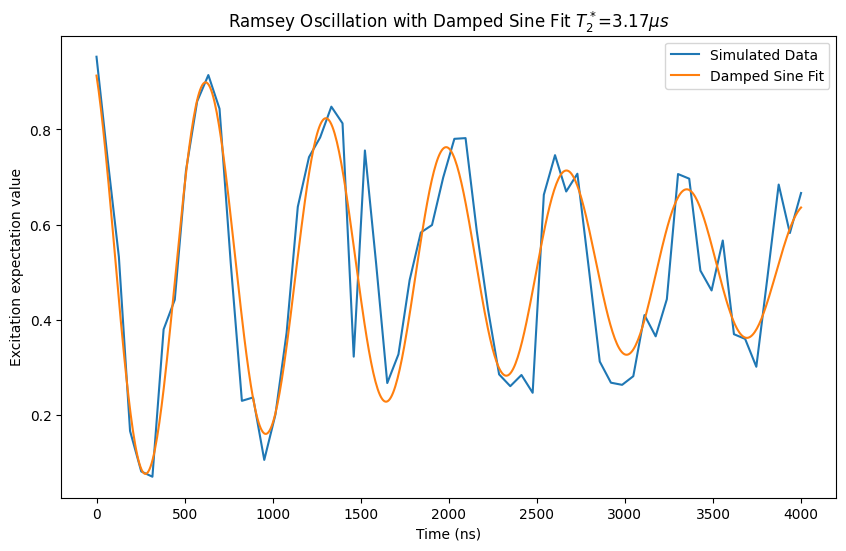

In [121]:
T=np.linspace(0,4000,64) #ns
def wrap_ramsey(T):
  return noisy_T_ramsey(T,noise_amp=0, T_noise=3)
exp=list(qtp.parallel_map(wrap_ramsey,T,))#progress_bar=True))
plot_ramsey(T,exp)

### 4 times Ed

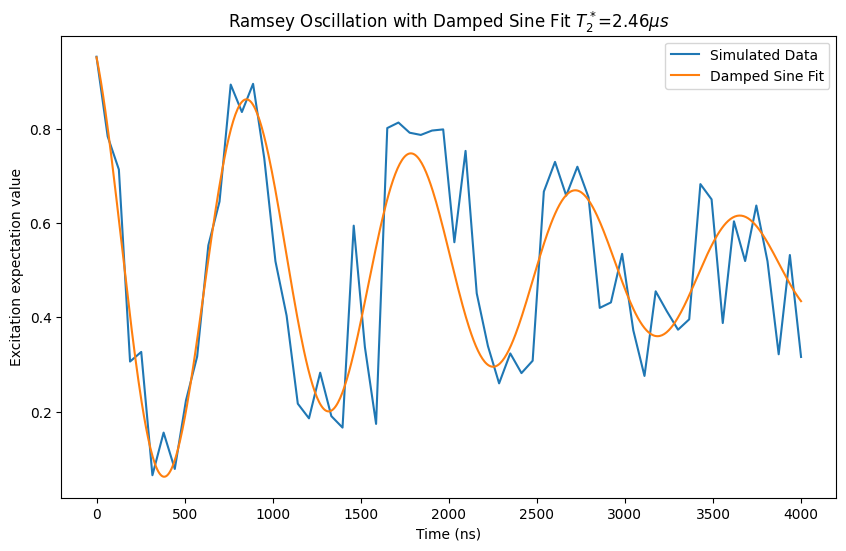

In [122]:
T=np.linspace(0,4000,64) #ns
def wrap_ramsey(T):
  return noisy_T_ramsey(T,noise_amp=0, T_noise=4)
exp=list(qtp.parallel_map(wrap_ramsey,T,))#progress_bar=True))
plot_ramsey(T,exp)

### 5 times Ed

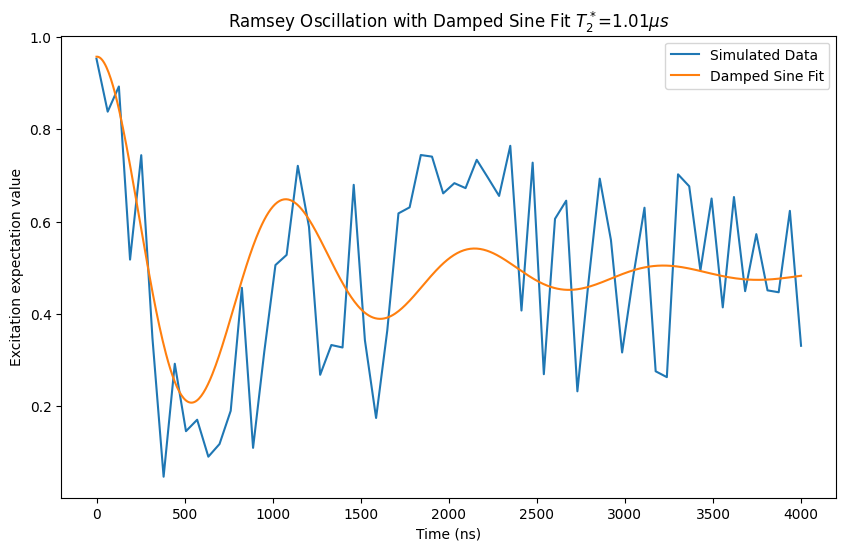

In [123]:
T=np.linspace(0,4000,64) #ns
def wrap_ramsey(T):
  return noisy_T_ramsey(T,noise_amp=0, T_noise=5)
exp=list(qtp.parallel_map(wrap_ramsey,T,))#progress_bar=True))
plot_ramsey(T,exp)

  # $T_2^{echo}$ simulation
Using $T_2^{echo}$ as a way to caracterize the dephasing we see that noise in the pulses will interfere with our measurement by causing drift from the resulting exponential curve that can even make the dephasing seem better than it really is (a greater time constant $T_2^{echo}$.

 By doing the measurement with noise only in between the pulses we can single out and confirm that this background noise in the drive of the qubit does cause dephasing. Though the amplitude necessary to cause a disruption is very significant.

In [124]:
def echo_plot(T, exp, T2_guess=2*T1):
  # prompt: plot the t2 echo exp with T and an exponential upside down non oscillating fit with the time constant in the title of the graph

  # Assuming T and exp are defined from the previous code block (T2 echo simulation)

  def exponential_decay(t, amplitude, decay_constant, offset):
      return amplitude * np.exp(-t / decay_constant) + offset

  params, covariance = curve_fit(exponential_decay, T, exp, p0=[-1, T2_guess, 0.5])

  amplitude, decay_constant, offset = params
  t_fit = np.linspace(T[0], T[-1], 1000)
  fitted_exp = exponential_decay(t_fit, amplitude, decay_constant, offset)


  fig, axes = plt.subplots(1, 1, figsize=(10, 6))
  axes.plot(T/1000, exp, label='Simulated Data')
  axes.plot(t_fit/1000, fitted_exp, label='Exponential Fit')
  axes.set_xlabel('Time ($\mu $s)')
  axes.set_ylabel('Excitation expectation value')
  axes.set_title(f'T2 Echo with Exponential Fit, $T_2^{{echo}}$={2*decay_constant/1000:.2f}$\mu s$')
  axes.legend()
  plt.show()

In [128]:
# initial state
psi0=qtp.basis(2,0)

 #drive parameters
Det=0 #[GHz]
pi2_pulse=np.pi/Ed/2 # [ns]
pi_pulse=np.pi/Ed # [ns]
wd=wq+Det*2*np.pi # [rad.GHz]
pure_drive=lambda t: Ed*(np.sin(wd*t)) # [rad.GHz]

T2=None

# time values for the time dependant simulation during excitation
# The time dependant part of the simulation is usually a bottleneck
# less points doesn't necessarily means less time/work

step=2 # ns
pi2_vec=np.linspace(0,pi2_pulse,256) # ns
pi_vec=np.linspace(0,pi_pulse,512) # ns

# dictionary with simulation options
# for T2 simulations we need higher numerical precision
# so we set atol and rtol that limit the (estimated) error
# per integration step to be smaller
options={"store_final_state":True,"nsteps":10000, "atol":1e-10,"rtol":1e-8}

def noisy_T_echo(T, noise_amp=0,T_noise=0,Ed=Ed):
  # Ramsey simulation with interrogation time T in [ns] and detuning Det in [GHz]

  # The ramsey osccillation is more inefficient to simulate than Rabi
  # Because you need to evolve the whole simulation for each interrogation time



  # Times for the free oscillation time independant simulation
  step=4 # ns
  t=np.arange(0,T+step,step) # ns

  #first drive pulse
  tlist=np.linspace(0,pi2_pulse+1,int(pi2_pulse*3000/wq)) # [ns]
  drive_data=pure_drive(tlist)+Ed*noise_amp*np.random.normal(0,1, tlist.shape) # [rad.GHz]


  # pi/2 pulse simulation with time dependant hamiltonian
  # it just simulates an excitation drive and returns the final state in the res_exc
  res=qtp.mesolve(H(wq,drive_data,tlist),psi0,pi2_vec*wq,c_ops(T1,T2),options=options)

  # shift to keep the phase consistent
  shift=pi2_vec[-1]

  # for T=0 or smaller than step not to throw an error
  if T>=step:
    if T_noise>0:
      tlist=shift+np.arange(0,T+1,100/wq) # [ns]
      noise_data=Ed*T_noise*np.random.normal(0,1, tlist.shape) # [rad.GHz]
      #Ramsey free evolution simulation
      res=qtp.mesolve(H(wq,noise_data,tlist),res.final_state,wq*(t+shift),c_ops(T1,T2),options=options)
    else:
      res=qtp.mesolve(H(wq,None,None),res.final_state,wq*(t+shift),c_ops(T1,T2),options=options)
    shift+=t[-1]

  #pi drive pulse
  tlist=shift+np.linspace(0,pi_pulse+1,int(pi_pulse*6000/wq)) # [ns]
  drive_data=pure_drive(tlist)+Ed*noise_amp*np.random.normal(0,1, tlist.shape) # [rad.GHz]
  res=qtp.mesolve(H(wq,drive_data,tlist),res.final_state,wq*(pi_vec+shift),c_ops(T1,T2),options=options)
  shift=pi_vec[-1]

  if T>=step:
    if T_noise>0:
      tlist=shift+np.arange(0,T+1,100/wq) # [ns]
      noise_data=Ed*T_noise*np.random.normal(0,1, tlist.shape) # [rad.GHz]
      #Ramsey free evolution simulation
      res=qtp.mesolve(H(wq,noise_data,tlist),res.final_state,wq*(t+shift),c_ops(T1,T2),options=options)
    else:
      res=qtp.mesolve(H(wq,None,None),res.final_state,wq*(t+shift),c_ops(T1,T2),options=options)
    shift+=t[-1]

  #second pi/2 drive pulse
  tlist=shift+np.linspace(0,pi2_pulse+1,int(pi2_pulse*3000/wq)) # [ns]
  drive_data=pure_drive(tlist)+Ed*noise_amp*np.random.normal(0,1, tlist.shape) # [rad.GHz]
  res=qtp.mesolve(H(wq,drive_data,tlist),res.final_state,wq*(pi2_vec+shift),c_ops(T1,T2),options=options)

  # return excitation expected value of the final state like a measurement
  return qtp.expect(n,res.final_state)

## No noise
Here we expect the time constant to be $T_2^\textrm{echo}=2T_1 = 4\mu s$ because we used no collapse operator in the simulation for the dephasing.

12.5%. Run time:   5.69s. Est. time left: 00:00:00:39
25.0%. Run time:  20.81s. Est. time left: 00:00:01:02
31.2%. Run time:  29.52s. Est. time left: 00:00:01:04
43.8%. Run time:  59.46s. Est. time left: 00:00:01:16
50.0%. Run time:  78.92s. Est. time left: 00:00:01:18
62.5%. Run time: 120.85s. Est. time left: 00:00:01:12
75.0%. Run time: 169.00s. Est. time left: 00:00:00:56
81.2%. Run time: 189.40s. Est. time left: 00:00:00:43
93.8%. Run time: 241.04s. Est. time left: 00:00:00:16
100.0%. Run time: 256.43s. Est. time left: 00:00:00:00
Total run time: 256.46s


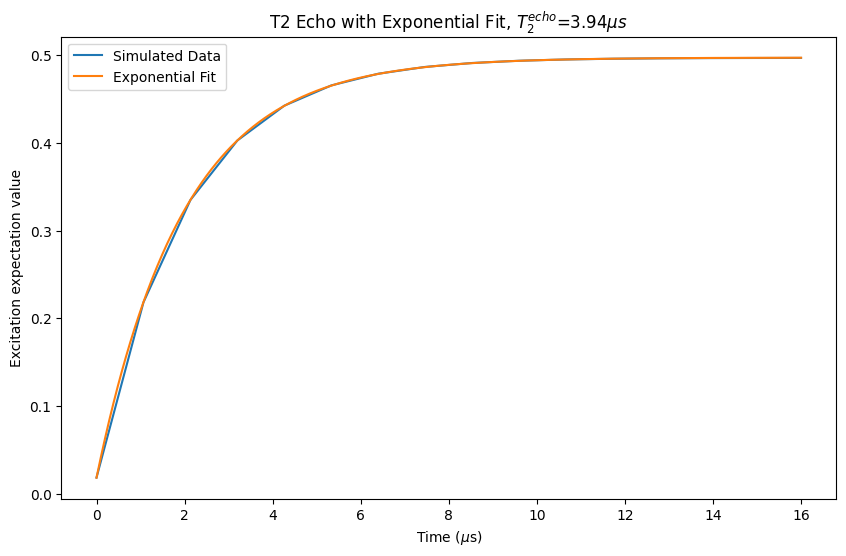

In [140]:
T=np.linspace(0,16000,16) # ns
def wrap_echo(T):
  return noisy_T_echo(T,noise_amp=0,T_noise=0)
exp=list(qtp.parallel_map(wrap_echo,T,progress_bar=True))
echo_plot(T,exp)


## Noisy pulse
A noisy pulse will greatly interfere with the measurment of the $T_2^\textrm{echo}$ time constant. Here in the simulation we see this constant become larger as the noise is increased clearly because the fit on the data generated is distorted.

### 1 time Ed

12.5%. Run time:   7.18s. Est. time left: 00:00:00:50
25.0%. Run time:  24.40s. Est. time left: 00:00:01:13
31.2%. Run time:  36.77s. Est. time left: 00:00:01:20
43.8%. Run time:  69.19s. Est. time left: 00:00:01:28
50.0%. Run time:  86.96s. Est. time left: 00:00:01:26
62.5%. Run time: 133.96s. Est. time left: 00:00:01:20
75.0%. Run time: 187.52s. Est. time left: 00:00:01:02
81.2%. Run time: 217.49s. Est. time left: 00:00:00:50
93.8%. Run time: 278.14s. Est. time left: 00:00:00:18
100.0%. Run time: 296.20s. Est. time left: 00:00:00:00
Total run time: 296.25s


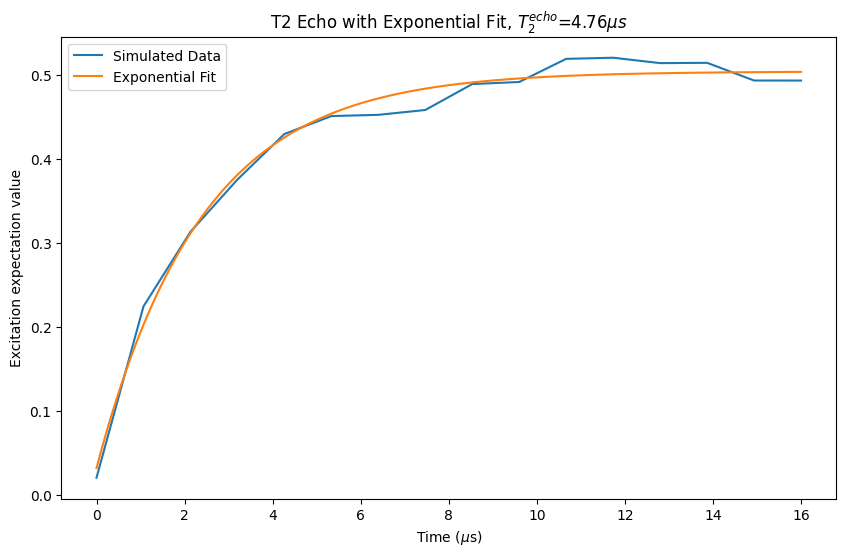

In [135]:
T=np.linspace(0,16000,16) # ns
def wrap_echo(T):
  return noisy_T_echo(T,noise_amp=1,T_noise=0)
exp=list(qtp.parallel_map(wrap_echo,T,progress_bar=True))
echo_plot(T,exp)

### 2 times Ed

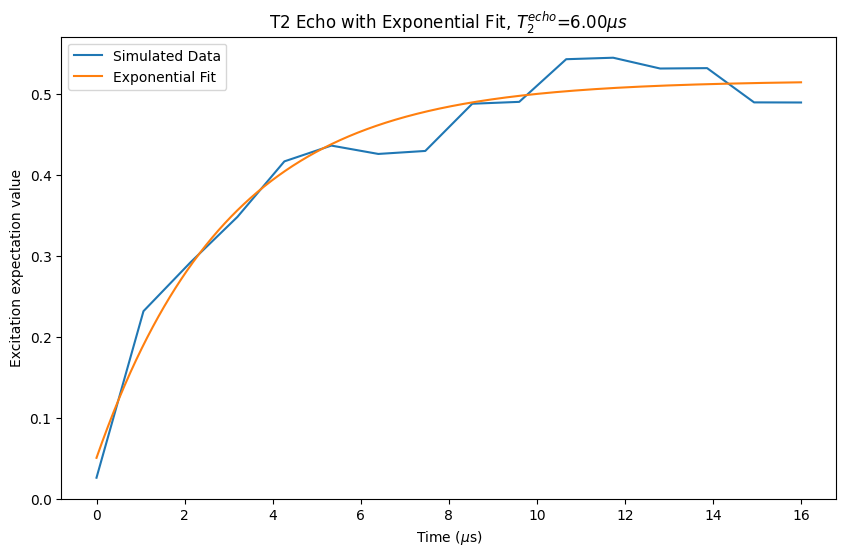

In [136]:
T=np.linspace(0,16000,16) # ns
def wrap_echo(T):
  return noisy_T_echo(T,noise_amp=2,T_noise=0)
exp=list(qtp.parallel_map(wrap_echo,T,))#progress_bar=True))
echo_plot(T,exp)

### 3 times Ed

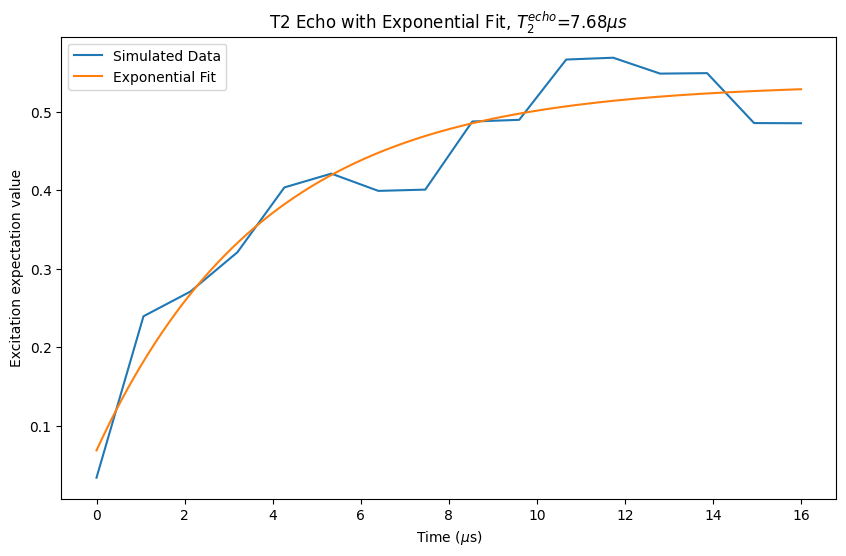

In [137]:
T=np.linspace(0,16000,16) # ns
def wrap_echo(T):
  return noisy_T_echo(T,noise_amp=3,T_noise=0)
exp=list(qtp.parallel_map(wrap_echo,T,))#progress_bar=True))
echo_plot(T,exp)

### 4 times Ed

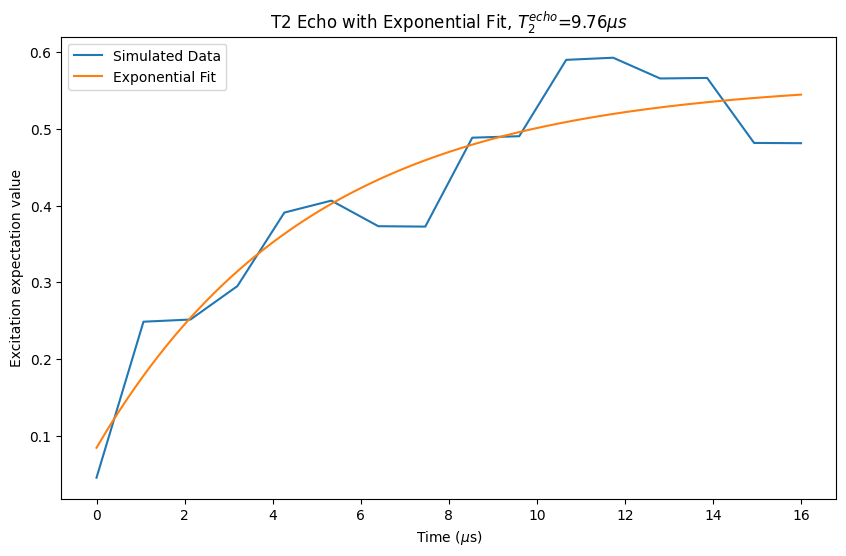

In [138]:
T=np.linspace(0,16000,16) # ns
def wrap_echo(T):
  return noisy_T_echo(T,noise_amp=4,T_noise=0)
exp=list(qtp.parallel_map(wrap_echo,T,))#progress_bar=True))
echo_plot(T,exp)

### 5 times Ed

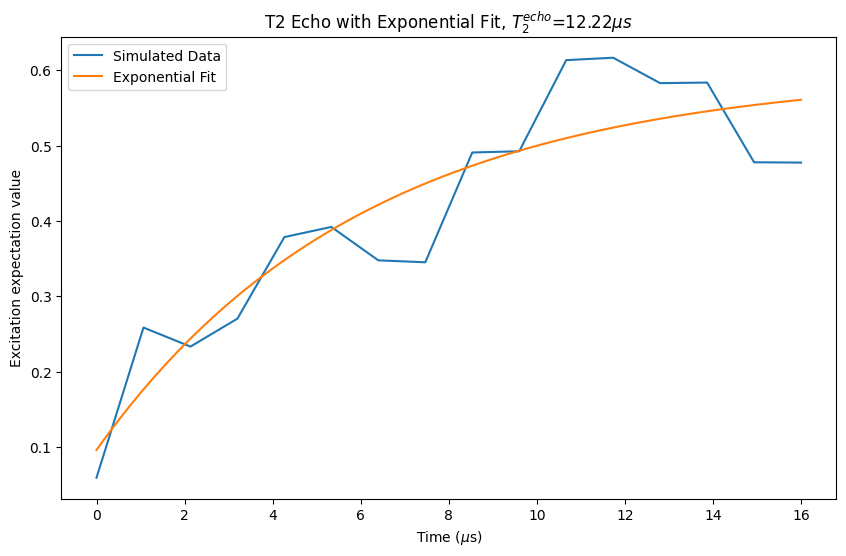

In [139]:
T=np.linspace(0,16000,16) # ns
def wrap_echo(T):
  return noisy_T_echo(T,noise_amp=5,T_noise=0)
exp=list(qtp.parallel_map(wrap_echo,T,))#progress_bar=True))
echo_plot(T,exp)

## Background noise in the intervals between pulses
We can confirm here that a background noise in the spaces in between the pulses will cause dephasing.

### 1 time Ed

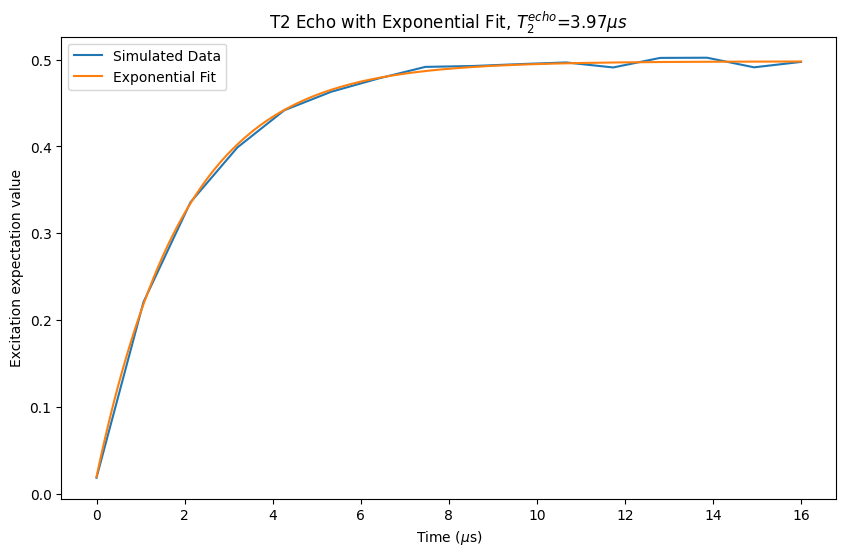

In [141]:
T=np.linspace(0,16000,16) # ns
def wrap_echo(T):
  return noisy_T_echo(T,noise_amp=0,T_noise=1)
exp=list(qtp.parallel_map(wrap_echo,T,))#progress_bar=True))
echo_plot(T,exp)

### 2 times Ed

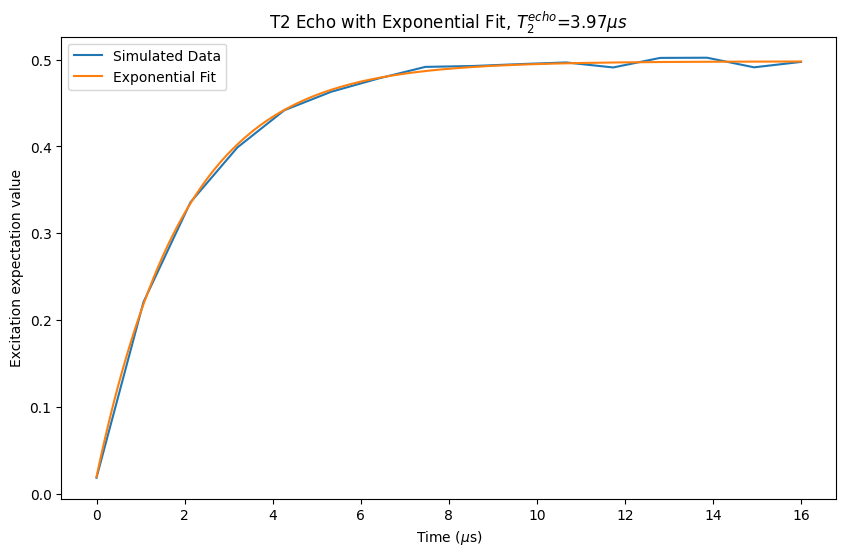

In [142]:
T=np.linspace(0,16000,16) # ns
def wrap_echo(T):
  return noisy_T_echo(T,noise_amp=0,T_noise=1)
exp=list(qtp.parallel_map(wrap_echo,T,))#progress_bar=True))
echo_plot(T,exp)

### 3 times Ed

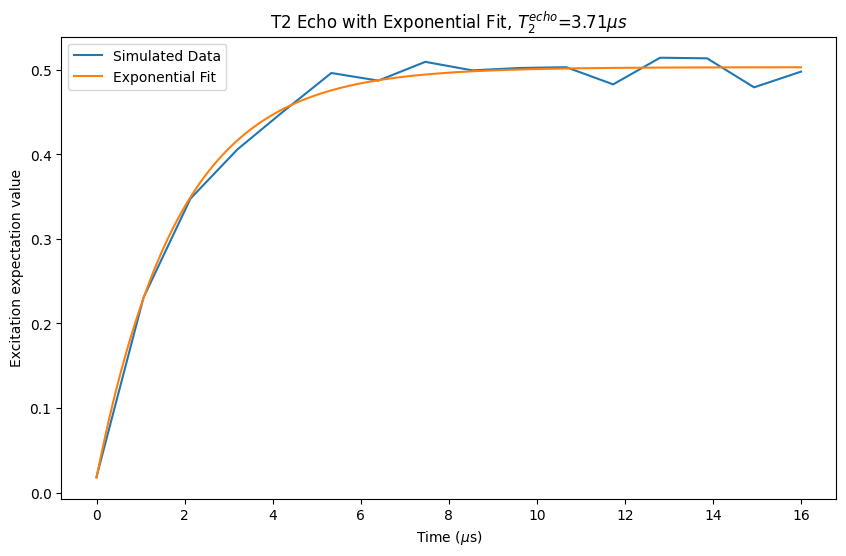

In [143]:
T=np.linspace(0,16000,16) # ns
def wrap_echo(T):
  return noisy_T_echo(T,noise_amp=0,T_noise=3)
exp=list(qtp.parallel_map(wrap_echo,T,))#progress_bar=True))
echo_plot(T,exp)

### 4 times Ed

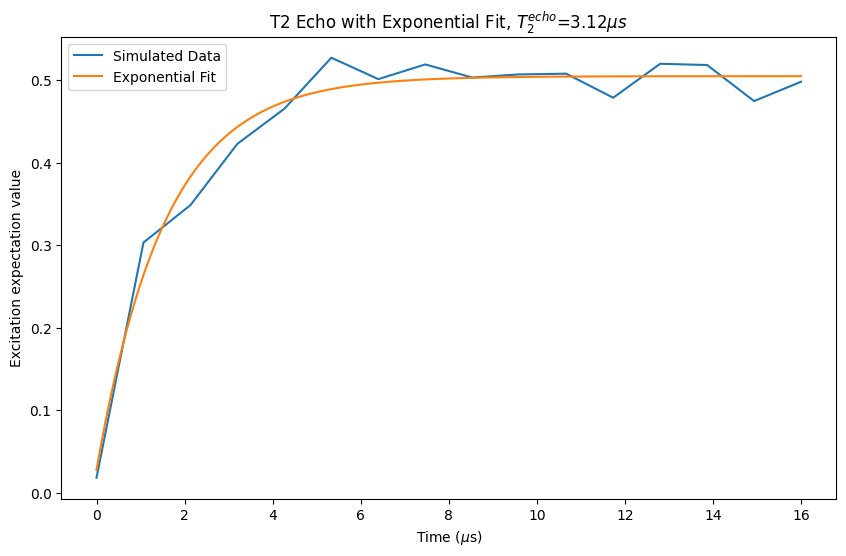

In [144]:
T=np.linspace(0,16000,16) # ns
def wrap_echo(T):
  return noisy_T_echo(T,noise_amp=0,T_noise=4)
exp=list(qtp.parallel_map(wrap_echo,T,))#progress_bar=True))
echo_plot(T,exp)

### 5 times Ed

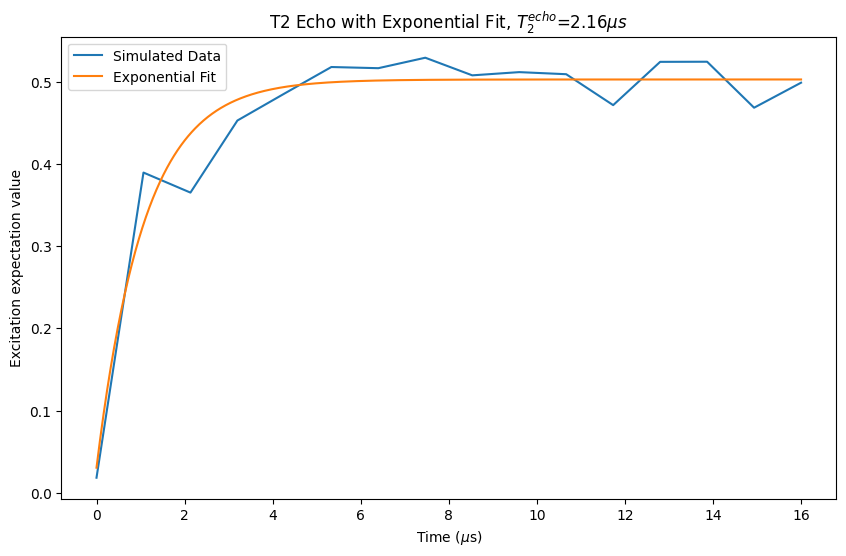

In [145]:
T=np.linspace(0,16000,16) # ns
def wrap_echo(T):
  return noisy_T_echo(T,noise_amp=0,T_noise=5)
exp=list(qtp.parallel_map(wrap_echo,T,))#progress_bar=True))
echo_plot(T,exp)